In [1]:
import os
credential=os.environ['HF_TOKEN']

In [2]:
%%capture
%pip install --no-cache "data-prep-toolkit-transforms[gneissweb_classification]"
%pip install huggingface_hub
%pip install matplotlib
%pip install pandas

In [3]:
from huggingface_hub import hf_hub_download
import pandas as pd

REPO_ID = "HuggingFaceFW/fineweb"
FILENAME = "data/CC-MAIN-2013-20/000_00000.parquet"
file1 = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, repo_type="dataset")
input_folder= os.path.dirname(file1)

/Users/touma/data-prep-kit-pkg/examples/notebooks/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
%%time
from dpk_gneissweb_classification import Classification

Classification(input_folder= input_folder,
        output_folder= "tmp/fastText/category_classifier",
        gcls_model_file_name= ["fasttext_medical.bin","fasttext_education.bin","fasttext_technology_computing.bin", "fasttext_science.bin"],
        gcls_model_url= ["ibm-granite/GneissWeb.Med_classifier","ibm-granite/GneissWeb.Edu_classifier","ibm-granite/GneissWeb.Tech_classifier", "ibm-granite/GneissWeb.Sci_classifier"],
        gcls_n_processes=4,
        gcls_output_label_column_name= ["medical_label","education_label","technology_computing_label","science_label"],
        gcls_output_score_column_name= ["medical_score","education_score","technology_computing_score","science_score"],
        gcls_content_column_name= "text").transform()

11:30:34 INFO - parameters are : {'gcls_model_credential': None, 'gcls_model_file_name': ["['fasttext_medical.bin', 'fasttext_education.bin', 'fasttext_technology_computing.bin', 'fasttext_science.bin']"], 'gcls_model_url': ["['ibm-granite/GneissWeb.Med_classifier', 'ibm-granite/GneissWeb.Edu_classifier', 'ibm-granite/GneissWeb.Tech_classifier', 'ibm-granite/GneissWeb.Sci_classifier']"], 'gcls_content_column_name': 'text', 'gcls_output_label_column_name': ["['medical_label', 'education_label', 'technology_computing_label', 'science_label']"], 'gcls_output_score_column_name': ["['medical_score', 'education_score', 'technology_computing_score', 'science_score']"], 'gcls_n_processes': 4}
11:30:34 INFO - pipeline id pipeline_id
11:30:34 INFO - code location None
11:30:34 INFO - data factory data_ is using local data access: input_folder - /Users/touma/.cache/huggingface/hub/datasets--HuggingFaceFW--fineweb/snapshots/0f039043b23fe1d4eed300b504aa4b4a68f1c7ba/data/CC-MAIN-2013-20 output_folde

CPU times: user 31.9 s, sys: 1min 3s, total: 1min 34s
Wall time: 11min 13s


0

In [2]:
import pandas as pd
df = pd.read_parquet('tmp/fastText/category_classifier/000_00000.parquet')

In [6]:
df.columns

Index(['text', 'id', 'dump', 'url', 'date', 'file_path', 'language',
       'language_score', 'token_count', 'medical_label', 'medical_score',
       'education_label', 'education_score', 'technology_computing_label',
       'technology_computing_score', 'science_label', 'science_score'],
      dtype='object')

In [7]:
#df['medical_score'].unique()

<Axes: >

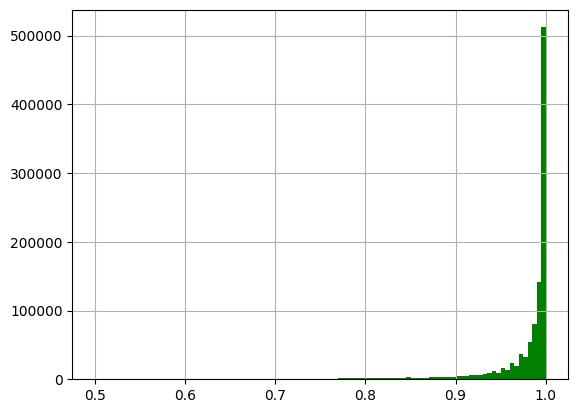

In [10]:
import matplotlib.pyplot as plt
df['medical_score'].hist(bins=100, color="green")

<Axes: >

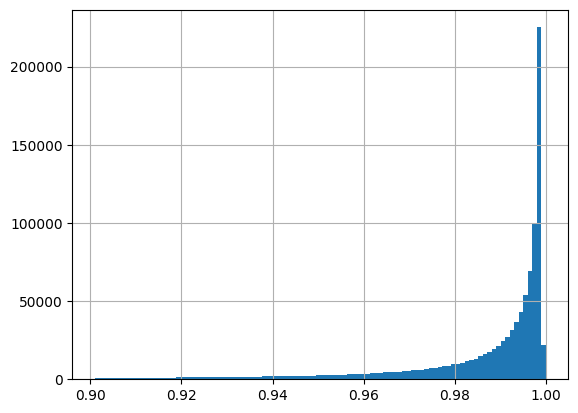

In [4]:
import matplotlib.pyplot as plt
#df['education_score'].hist(bins=100, color = "blue")
df[df['medical_score']> 0.9]['medical_score'].hist(bins=100)

<Axes: >

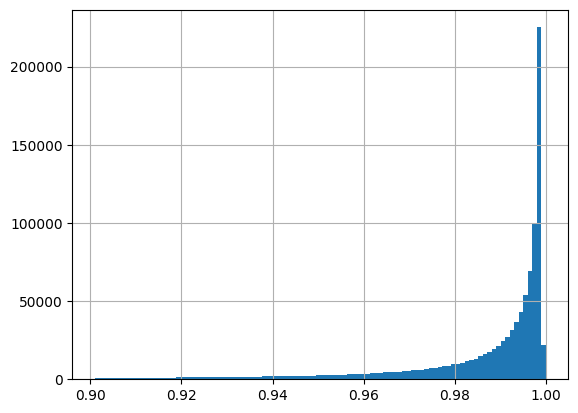

In [4]:
import matplotlib.pyplot as plt
#df['education_score'].hist(bins=100, color = "blue")
df[df['medical_score']> 0.9]['medical_score'].hist(bins=100)

<Axes: >

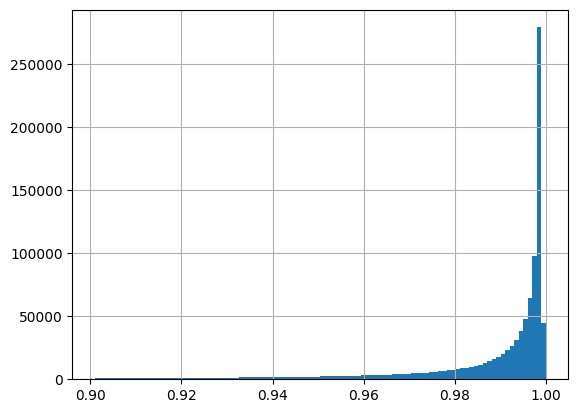

In [5]:
import matplotlib.pyplot as plt
#df['education_score'].hist(bins=100, color = "blue")
df[df['education_score']> 0.9]['education_score'].hist(bins=100)

<Axes: >

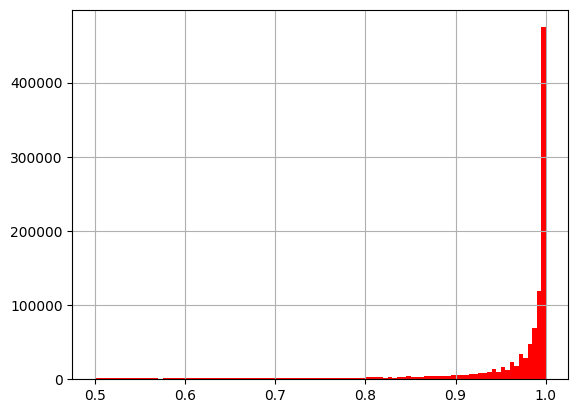

In [9]:
import matplotlib.pyplot as plt
df['technology_computing_score'].hist(bins=100, color = "red")